In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


# Basic characteristics for a plot
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False


In [88]:
# Function used to format the labels
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

def billions_formatter2(x, pos):
    return f"{x:,.1f}B"


In [89]:
df = pd.read_csv(r"data\Symbol_Info_extended.csv")

# First of all we do a summary of the features of each table and possible NA values
summary = pd.DataFrame({
    "column" : df.columns,
    "dtype" : df.dtypes.astype(str).values,
    "missing_values" : df.isna().sum().values,
})

print(summary)
print(df.head())


# My Student ID is 1000066172 so we take as country Canada
df_can = df[df["country"] == "Canada"].copy()

# Small check to se if there are values
print(df_can.head())
print("Number of rows : ",df_can.shape[0])

# Creating column market capitalization in billions
df_can["market_cap_b"] = df_can["market_cap"]/1e9


              column    dtype  missing_values
0             symbol   object               0
1       company_name   object              99
2             sector   object             101
3           industry   object             101
4            country   object             100
5         market_cap  float64             100
6         net_income  float64             106
7      total_revenue  float64             187
8   return_on_assets  float64             119
9   return_on_equity  float64             262
10    profit_margins  float64             100
11       pe_trailing  float64             975
12        pe_forward  float64             165
13   earnings_growth  float64            1284
14    price_to_sales  float64             190
15     price_to_book  float64              96
16    revenue_growth  float64             222
17    debt_to_equity  float64             542
18    dividend_yield  float64            1480
19      payout_ratio  float64             103
20     free_cashflow  float64     

## Step 0


In [ ]:
# We want to select the company corresponding to the median in market capitalization 
df_best = df_can[df_can["market_cap"] == df_can["market_cap"].median()]
print(f"Selected Company: {df_best["company_name"].values[0]}")


Selected Company: First Majestic Silver Corp.


## Step 1


In [91]:
# Taking only the features that matter for the analysis
df_analysis = df_can[["symbol", "company_name", "sector", "industry", "country", "market_cap","return_on_assets", "return_on_equity", "profit_margins","pe_trailing", "price_to_book", "revenue_growth", "debt_to_equity", "free_cashflow","market_cap_b"]].copy()

# Replacing infinite values with NaN
df_analysis = df_analysis.replace([np.inf, -np.inf], np.nan)

# Taking only firms with a positive market capitalization
df_analysis = df_analysis[(df_analysis["market_cap"] > 0)]

#Assessing if there are negative values for pe trailing and price to book
df_negative_pe = df_analysis[df_analysis["pe_trailing"]<0]
df_negative_price = df_analysis[df_analysis["price_to_book"]<0]
print(f"Number of negative pe_trailing: {df_negative_pe.shape[0]}\nNumber of negative pe_trailing: {df_negative_price.shape[0]}\n")

# Substituting negative values with NaN values
df_analysis.loc[df_analysis["pe_trailing"]<0, "pe_trailing"] = np.nan
df_analysis.loc[df_analysis["price_to_book"]<0, "price_to_book"] = np.nan

# Check if the code does it
df_negative_pe = df_analysis[df_analysis["pe_trailing"]<0]
df_negative_price = df_analysis[df_analysis["price_to_book"]<0]
print(f"Number of negative pe_trailing: {df_negative_pe.shape[0]}\nNumber of negative pe_trailing: {df_negative_price.shape[0]}")



Number of negative pe_trailing: 0
Number of negative pe_trailing: 3

Number of negative pe_trailing: 0
Number of negative pe_trailing: 0


## Step 2


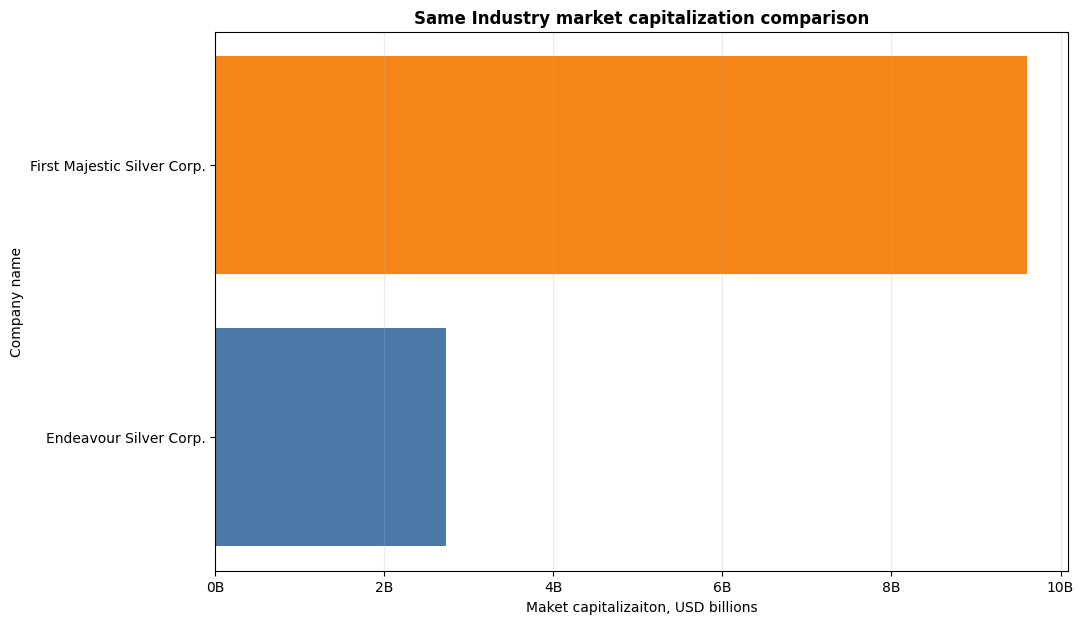

In [92]:
# Group A

# Selecting the same industry of the chosen company
df_industry = df_analysis[df_analysis["industry"] == str(df_best["industry"].values[0])].copy()

# Sorting 
df_industry = df_industry.nlargest(10,"market_cap_b")
df_industry = df_industry.sort_values("market_cap_b",ascending = True)

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))

# Creating the color palette that underlying our chosed company with another color
normal_color = "#4C78A8"
selected_company = "#F58518"
colors = [selected_company if df_industry.loc[c]["company_name"] == df_best["company_name"].values[0] 
          else normal_color for c in df_industry.index]

# Plotting and formatting
ax.barh(
    df_industry["company_name"],
    df_industry["market_cap_b"],
    color = colors
    )
ax.set_title("Same Industry market capitalization comparison")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)



The chosen company is not on the list. It's added


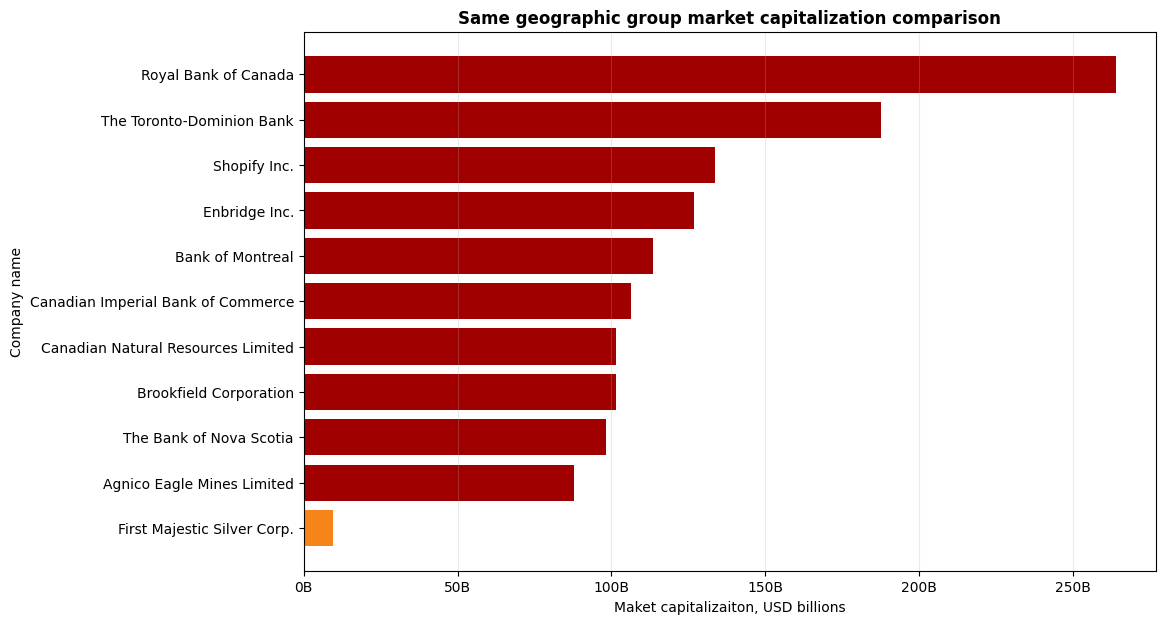

In [93]:
# Group B

# Sorting by market capitalization company for same geographic group
df_sort_geo = df_analysis.nlargest(10,"market_cap_b")

# Seeing if the company is not on the list. If it is not, add it
j = 1
for i in df_sort_geo.index:
    if df_sort_geo.loc[i]["company_name"] == df_best["company_name"].values[0]:
        print("The company is inside the sorted list")
        j = 0
        break
if j == 1:
    print("The chosen company is not on the list. It's added")
    df_sort_geo = pd.concat([df_sort_geo,df_best])

# Sorting all 
df_sort_geo = df_sort_geo.sort_values("market_cap_b",ascending = True)

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))


# Creating the color palette that underlying our chosed company with another color
normal_color = "#a00000"
selected_company = "#F58518"
colors = [selected_company if df_sort_geo.loc[c]["company_name"] == df_best["company_name"].values[0] 
          else normal_color for c in df_sort_geo.index]

# Plotting and formatting
ax.barh(
    df_sort_geo["company_name"],
    df_sort_geo["market_cap_b"],
    color = colors
    )
ax.set_title("Same geographic group market capitalization comparison")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)


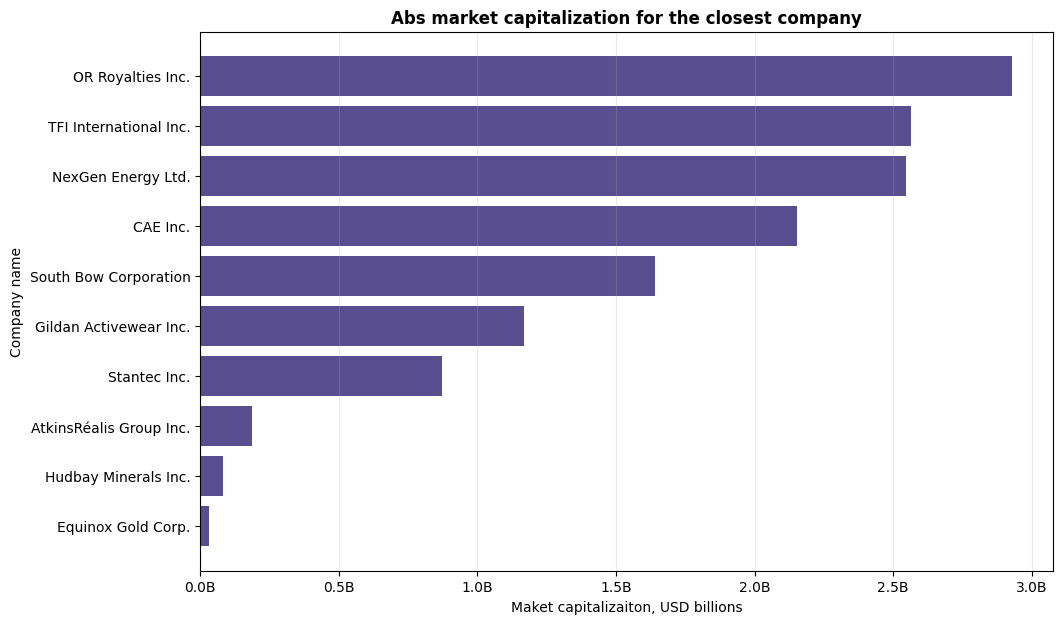

In [ ]:
# Group C

# Creating a new dataframe in which there is another feature that containse the
# absolute deviation from the market capitalization of the refered company 
df_abs = df_analysis.copy()
df_abs["abs"] = df_abs["market_cap_b"].apply(lambda c : abs(c-df_best["market_cap_b"].values[0])) 


# Sorting 
df_abs = df_abs.nsmallest(n = 11,columns = "abs",keep = "all")
df_abs = df_abs.sort_values("abs",ascending=True)

# Dropping the chosen company
df_abs_clean = df_abs.drop(df_abs[df_abs["company_name"] == str(df_best["company_name"].values[0])].index)

# Creating a bar plot to compare them
fig, ax = plt.subplots(figsize = (11,7))

# Plotting and formatting
ax.barh(
    df_abs_clean["company_name"],
    df_abs_clean["abs"],
    color = "#594e90"
    )
ax.set_title("Abs market capitalization for the closest company")
ax.set_xlabel("Maket capitalizaiton, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter2))
ax.set_ylabel("Company name")
ax.grid(axis="x",alpha = 0.25)
